# Continuous Size Estimation — Using .pkl data

In [49]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'TF Hub:     {hub.__version__}')
print(f'GPUs:       {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.21.0
TF Hub:     0.16.1
GPUs:       []


## Configuration

In [50]:
TRAIN_PKL = '../data/folds-w-meta.pkl'
TEST_PKL  = '../data/test-w-meta.pkl'

EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'
ESTIMATE_IMAGE_SIZE = (224, 224)
BATCH_SIZE          = 32
ESTIMATOR_EPOCHS    = 30
SEED                = 42

TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

# Bin definitions are kept around so we can still report bin-level accuracy
# at evaluation time for comparison with Silva — but the model trains on raw mm.
BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
BIN_LABELS = ['10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None

In [51]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

train_pkl_folds = load_pkl(TRAIN_PKL)
test_pkl_folds  = load_pkl(TEST_PKL)

print(f'Train pkl folds: {len(train_pkl_folds)}')
print(f'Keys per fold:   {list(train_pkl_folds[0].keys())}')
print(f'Fold 0 size:     {len(train_pkl_folds[0]["data"])} fish')
print(f'Test pkl folds:  {len(test_pkl_folds)}')


Train pkl folds: 10
Keys per fold:   ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Fold 0 size:     63 fish
Test pkl folds:  1


In [52]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and
    (N,) float32 lengths in mm. Each fish contributes 9 image entries.
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            length_mm = float(length)

            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(length_mm)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [53]:
print('Building train set...')
X_train, y_train = folds_to_arrays(train_pkl_folds, TRAIN_FOLDS)
print('Building val set...')
X_val,   y_val   = folds_to_arrays(train_pkl_folds, VAL_FOLDS)
print('Building test set...')
X_test,  y_test  = folds_to_arrays(test_pkl_folds)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train lengths — min: {y_train.min():.0f}mm, '
      f'max: {y_train.max():.0f}mm, mean: {y_train.mean():.1f}mm')
print(f'Test  lengths — min: {y_test.min():.0f}mm,  '
      f'max: {y_test.max():.0f}mm, mean: {y_test.mean():.1f}mm')

Building train set...
  Loaded 5049 images from 561 fish, skipped 0 fish
Building val set...
  Loaded 558 images from 62 fish, skipped 0 fish
Building test set...
  Loaded 639 images from 71 fish, skipped 0 fish

Train: 5049  Val: 558  Test: 639
Train lengths — min: 183mm, max: 910mm, mean: 490.4mm
Test  lengths — min: 284mm,  max: 860mm, mean: 512.8mm


In [54]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

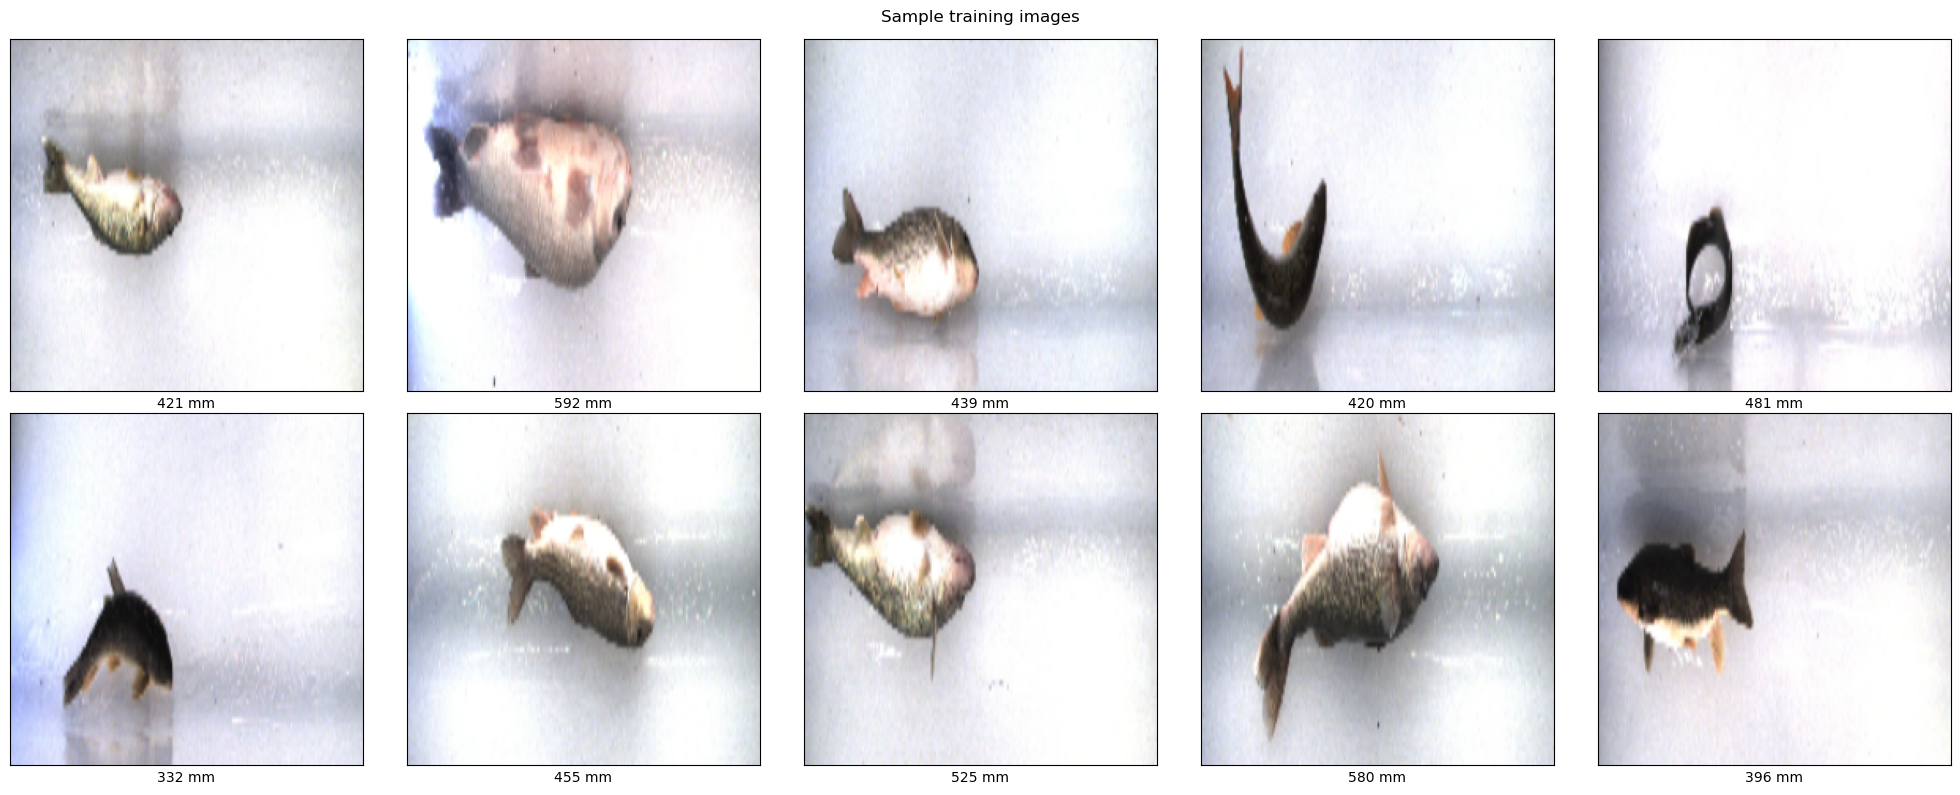

In [55]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build model

In [56]:
def build_estimator(trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1),                       # single continuous output, no activation
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',                                     
        metrics=['mae'],                                
    )
    return model

estimator = build_estimator(trainable_backbone=False)
estimator.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_5 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 keras_layer_5 (KerasLayer)  (None, 1280)              3413024   
                                                                 
 dropout_5 (Dropout)         (None, 1280)              0         
                                                                 
 dense_9 (Dense)             (None, 128)               163968    
                                                                 
 dense_10 (Dense)            (None, 1)                 129       
                                                                 
Total params: 3577121 (13.65 MB)
Trainable params: 164097 (641.00 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train

In [57]:
early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS,
    callbacks=[early_stop],
)


Epoch 1/30
158/158 [==============================] - 19s 109ms/step - loss: 94605.5156 - mae: 252.6014 - val_loss: 15891.2012 - val_mae: 101.4038
Epoch 2/30
158/158 [==============================] - 16s 101ms/step - loss: 12474.3086 - mae: 87.3762 - val_loss: 12010.3789 - val_mae: 88.3582
Epoch 3/30
158/158 [==============================] - 16s 102ms/step - loss: 9303.2266 - mae: 75.6298 - val_loss: 8815.0713 - val_mae: 74.8798
Epoch 4/30
158/158 [==============================] - 16s 103ms/step - loss: 7084.5547 - mae: 65.8471 - val_loss: 6871.1807 - val_mae: 65.5982
Epoch 5/30
158/158 [==============================] - 16s 102ms/step - loss: 5866.8989 - mae: 59.8777 - val_loss: 5734.8721 - val_mae: 59.3400
Epoch 6/30
158/158 [==============================] - 16s 104ms/step - loss: 5206.9023 - mae: 56.0028 - val_loss: 5118.3994 - val_mae: 55.2608
Epoch 7/30
158/158 [==============================] - 17s 107ms/step - loss: 4766.1074 - mae: 53.1145 - val_loss: 4681.0112 - val_mae: 5

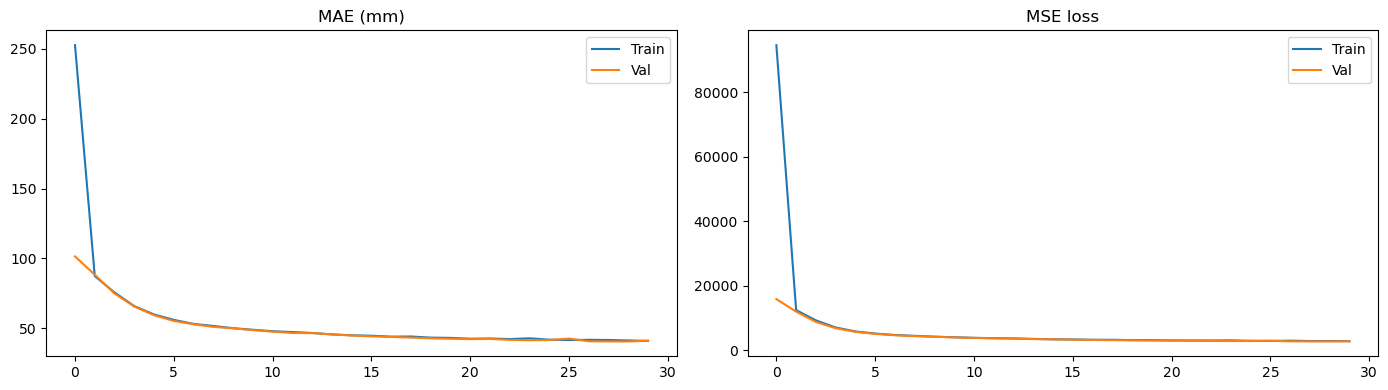

Train  — MSE: 2127.7, MAE: 34.8 mm (3.5 cm)
Val    — MSE: 2761.9, MAE: 40.6 mm (4.1 cm)
Test   — MSE: 2939.5, MAE: 40.3 mm (4.0 cm)


In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['mae'],     label='Train')
ax1.plot(history.history['val_mae'], label='Val')
ax1.set_title('MAE (mm)'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('MSE loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, mae = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — MSE: {loss:.1f}, MAE: {mae:.1f} mm ({mae/10:.1f} cm)')

## Confusion Matrix

Per-image MAE: 40.3 mm (4.0 cm)
Per-fish MAE:  24.3 mm (2.4 cm)
Best-fit slope:     0.860  (1.0 = unbiased)
Best-fit intercept: 81.2 mm


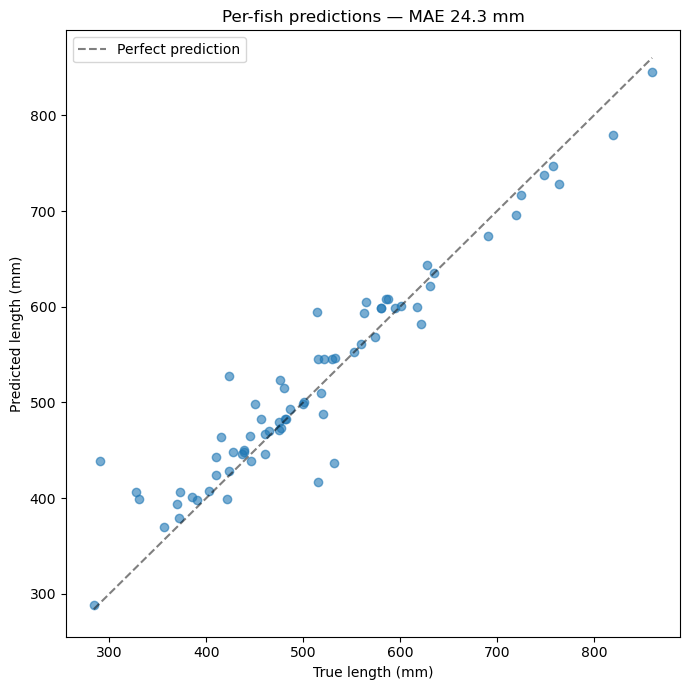

Per-fish bin accuracy: 76.06%


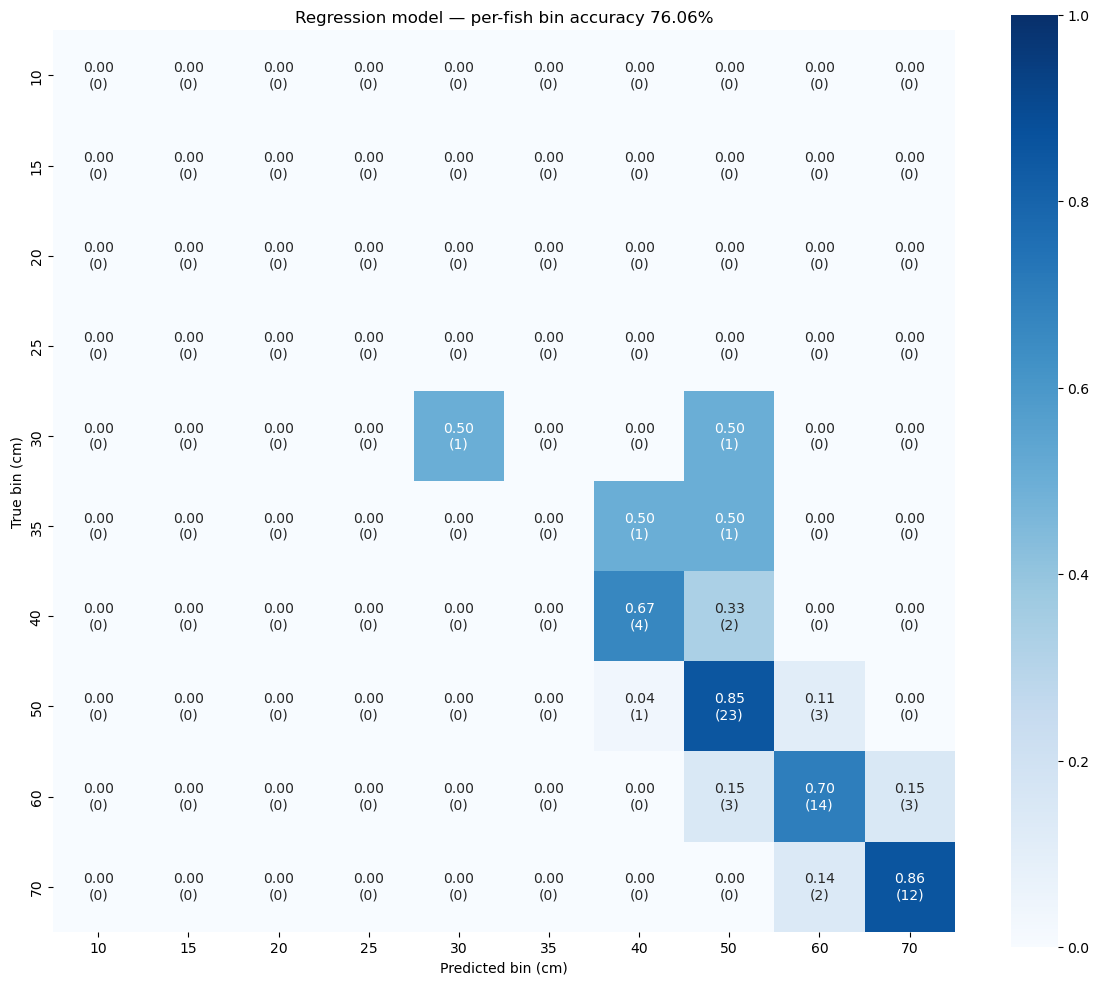

In [60]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Per-image predictions
preds_mm = estimator.predict(X_test, verbose=0).squeeze()       # (N*9,)

# Per-fish predictions: average the 9 view-level length estimates
preds_per_fish    = preds_mm.reshape(-1, 9).mean(axis=1)        # (N_fish,)
y_true_per_fish   = y_test.reshape(-1, 9)[:, 0]

per_image_mae = np.mean(np.abs(preds_mm - y_test))
per_fish_mae  = np.mean(np.abs(preds_per_fish - y_true_per_fish))
print(f'Per-image MAE: {per_image_mae:.1f} mm ({per_image_mae/10:.1f} cm)')
print(f'Per-fish MAE:  {per_fish_mae:.1f} mm ({per_fish_mae/10:.1f} cm)')

slope, intercept = np.polyfit(y_true_per_fish, preds_per_fish, 1)
print(f'Best-fit slope:     {slope:.3f}  (1.0 = unbiased)')
print(f'Best-fit intercept: {intercept:.1f} mm')

# Scatter: true vs predicted (per fish)
plt.figure(figsize=(7, 7))
lo, hi = min(y_true_per_fish.min(), preds_per_fish.min()), max(y_true_per_fish.max(), preds_per_fish.max())
plt.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect prediction')
plt.scatter(y_true_per_fish, preds_per_fish, alpha=0.6)
plt.xlabel('True length (mm)'); plt.ylabel('Predicted length (mm)')
plt.title(f'Per-fish predictions — MAE {per_fish_mae:.1f} mm')
plt.legend(); plt.tight_layout(); plt.show()

# Bin-level accuracy for direct comparison with Silva: convert predictions
# and ground truth back into bins, then build a confusion matrix.
def lengths_to_bins(lengths_mm):
    bins = np.array([length_to_bin(L) for L in lengths_mm])
    bins[bins == None] = NUM_SIZE_BINS - 1  # clip out-of-range to last bin
    return bins.astype(int)

y_pred_bins = lengths_to_bins(preds_per_fish)
y_true_bins = lengths_to_bins(y_true_per_fish)
bin_acc = np.mean(y_pred_bins == y_true_bins)
print(f'Per-fish bin accuracy: {bin_acc:.2%}')

cm      = confusion_matrix(y_true_bins, y_pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Regression model — per-fish bin accuracy {bin_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()